# Decision Tree (Pohon Keputusan)

adalah algoritma dalam Machine Learning yang digunakan untuk klasifikasi, dengan bentuk seperti pohon (tree) yang mudah dipahami.

Decision Tree bekerja dengan cara memecah data menjadi cabang-cabang berdasarkan kondisi tertentu.
Struktur utamanya:
* Root (akar) → pertanyaan pertama
* Node (simpul) → percabangan berdasarkan fitur
* Leaf (daun) → hasil akhir (kelas atau nilai)

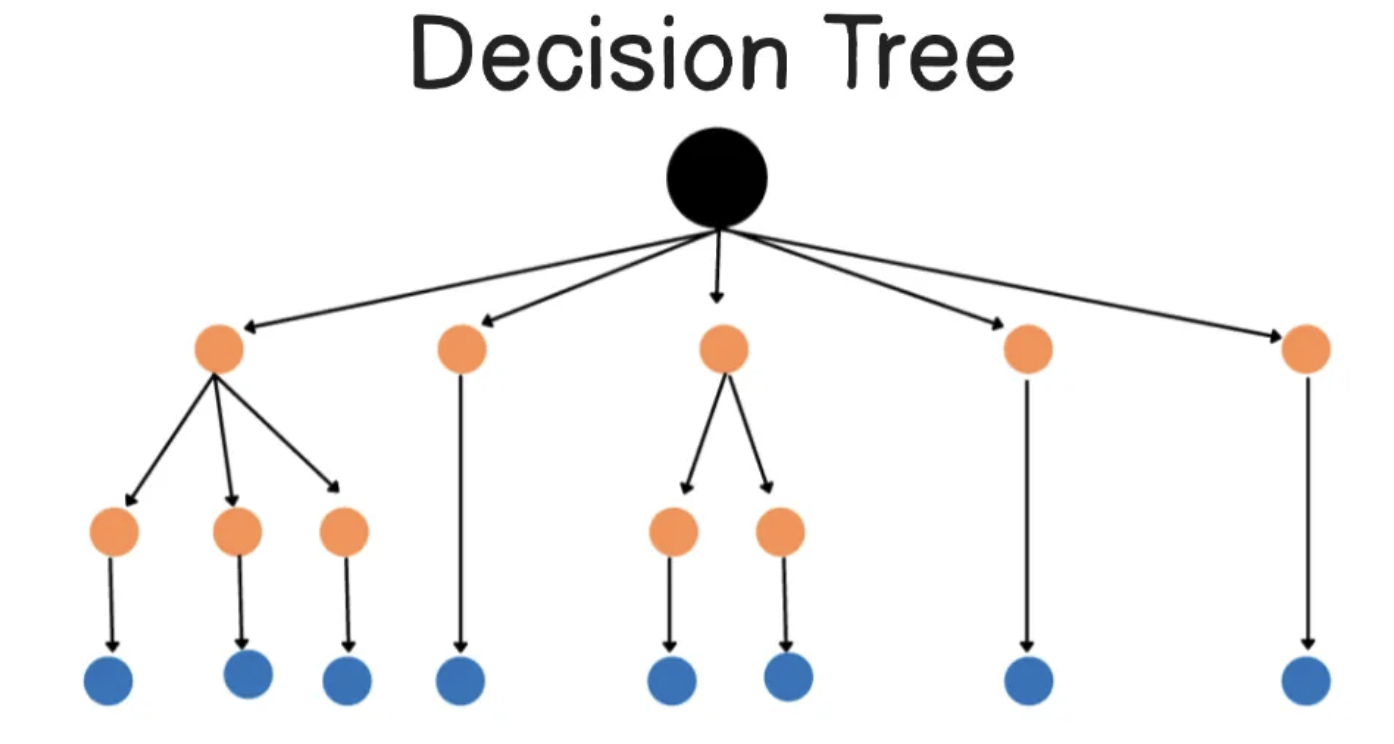

# Kriteria Pemilihan Split (menjadi cabang)
1. Entropy
Mengukur ketidakpastian.
Semakin kecil entropy → semakin “rapi” datanya.


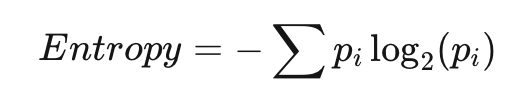

2. Information Gain
Mengukur seberapa baik split.
Model memilih split dengan IG terbesar.

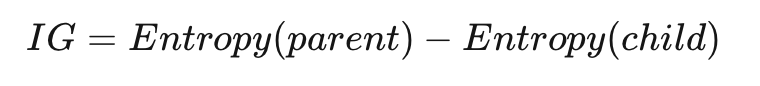

In [1]:
# 1. Import Library yang Diperlukan
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

In [2]:
# 2. Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
!ls /content/drive/MyDrive/ML/klasifikasi/

ls: cannot access '/content/drive/MyDrive/ML/klasifikasi/': No such file or directory


In [4]:
# 3. Muat Dataset - Ditambahkan di sini untuk memastikan df terdefinisi
# Sesuaikan path ini dengan lokasi file Anda di Google Drive
file_path = '/content/drive/MyDrive/ML/penjualan_mobil.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset berhasil dimuat!")
    print(f"Jumlah Baris: {df.shape[0]}, Jumlah Kolom: {df.shape[1]}")
except FileNotFoundError:
    print(f"File tidak ditemukan di {file_path}. Pastikan path sudah benar.")
    # Hentikan eksekusi jika file tidak ada

Dataset berhasil dimuat!
Jumlah Baris: 215, Jumlah Kolom: 6


In [5]:
df.shape

(215, 6)

In [6]:
df.head()

,Merek,Tahun_Produksi,Kapasitas_Mesin,Jarak_Tempuh,Transmisi,Harga
0,Toyota,2005,2000,72097,Manual,69.83
1,Daihatsu,2007,1800,110604,Manual,53.78
2,Daihatsu,2005,1800,52124,Automatic,73.30
3,Toyota,2010,2000,110785,Automatic,88.21
4,Suzuki,2008,1000,99595,Manual,28.44


In [7]:
# 4. Pra-pemrosesan Data (Preprocessing)
# Untuk memastikan X_encoded, y_encoded terdefinisi

# Pisahkan Fitur (X) dan Target (y)
X = df.drop('Transmisi', axis=1)
y = df['Transmisi']

# Encoding Target (Label Encoding)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Encoding Fitur Kategorikal (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

In [8]:
# 5. Split Data (Training & Testing) - Ditambahkan di sini untuk memastikan X_train, y_train terdefinisi
# 70% data latih, 30% data uji
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42)


In [9]:
# 6. Feature Scaling (Diulang di sini untuk memastikan variabel scaling tersedia)
# Menyamakan skala semua fitur numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [10]:
# 7. Membuat dan Melatih Model Decision Tree
print("\nMelatih model Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=42) # Inisialisasi Decision Tree Classifier
dt_model.fit(X_train_scaled, y_train)


Melatih model Decision Tree...


DecisionTreeClassifier(random_state=42)

In [11]:
# 8. Prediksi dan Evaluasi Model Decision Tree
y_pred_dt = dt_model.predict(X_test_scaled)

# Hitung Akurasi
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nAkurasi Model Decision Tree : {accuracy_dt * 100:.2f}%")

# Tampilkan Classification Report
print("\nClassification Report (DT):")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))


Akurasi Model Decision Tree : 50.77%

Classification Report (DT):
              precision    recall  f1-score   support

   Automatic       0.51      0.58      0.54        33
      Manual       0.50      0.44      0.47        32

    accuracy                           0.51        65
   macro avg       0.51      0.51      0.50        65
weighted avg       0.51      0.51      0.51        65



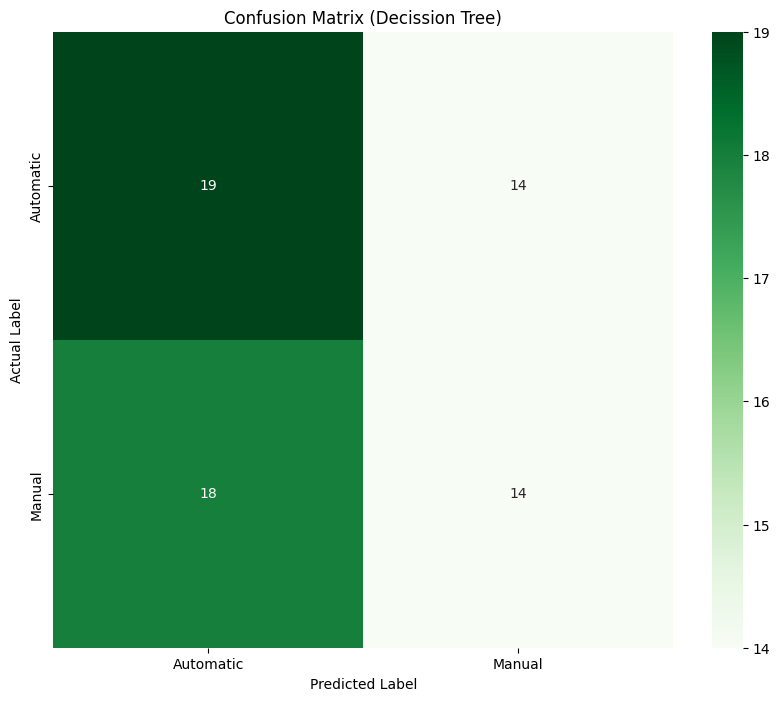

In [12]:

# 9. Visualisasi Confusion Matrix (Decision Tree)
cm_dt = confusion_matrix(y_test, y_pred_dt)
class_names = le.classes_
cm_df_dt = pd.DataFrame(cm_dt, index=class_names, columns=class_names)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df_dt, annot=True, fmt='g', cmap='Greens')
plt.title('Confusion Matrix (Decission Tree)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [13]:
# 9. Prediksi dengan Data Baru

# Contoh data baru (sesuaikan dengan format kolom asli df sebelum encoding)
# Pastikan urutan dan nama kolom sesuai dengan X (sebelum one-hot encoding)
new_data = pd.DataFrame([
    {
        'Gender': 'Male',
        'Age': 25,
        'Height': 1.75,
        'Weight': 90,
        'family_history_with_overweight': 'yes',
        'FAVC': 'yes',
        'FCVC': 2,
        'NCP': 3,
        'CAEC': 'Sometimes',
        'SMOKE': 'no',
        'CH2O': 2,
        'SCC': 'no',
        'FAF': 1,
        'TUE': 1,
        'CALC': 'Sometimes',
        'MTRANS': 'Public_Transportation'
    },
    {
        'Gender': 'Female',
        'Age': 30,
        'Height': 1.60,
        'Weight': 55,
        'family_history_with_overweight': 'no',
        'FAVC': 'no',
        'FCVC': 3,
        'NCP': 2,
        'CAEC': 'Always',
        'SMOKE': 'no',
        'CH2O': 3,
        'SCC': 'no',
        'FAF': 2,
        'TUE': 0,
        'CALC': 'no',
        'MTRANS': 'Walking'
    }
])

# Terapkan One-Hot Encoding pada data baru
# Pastikan kolom-kolomnya sama dengan X_encoded
new_data_encoded = pd.get_dummies(new_data, drop_first=True)

# Reindex new_data_encoded to align columns with X_encoded (important for consistent feature order)
# Fill missing columns with 0, if any new_data category was not in training data
missing_cols = set(X_encoded.columns) - set(new_data_encoded.columns)
for c in missing_cols:
    new_data_encoded[c] = 0
new_data_encoded = new_data_encoded[X_encoded.columns]

# Skala data baru menggunakan scaler yang sudah dilatih
new_data_scaled = scaler.transform(new_data_encoded)

# Lakukan prediksi menggunakan rf_model
new_predictions_encoded = dt_model.predict(new_data_scaled)

# Ubah kembali hasil prediksi ke label asli
new_predictions_labels = le.inverse_transform(new_predictions_encoded)

print("\nData Baru Sebelum Encoding dan Scaling:")
display(new_data)

print("\nHasil Prediksi untuk Data Baru:")
for i, prediction in enumerate(new_predictions_labels):
    print(f"Data Baru {i+1}: {prediction}")


Data Baru Sebelum Encoding dan Scaling:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,Male,25,1.75,90,yes,yes,2,3,Sometimes,no,2,no,1,1,Sometimes,Public_Transportation
1,Female,30,1.60,55,no,no,3,2,Always,no,3,no,2,0,no,Walking



Hasil Prediksi untuk Data Baru:
Data Baru 1: Manual
Data Baru 2: Manual


In [14]:
import gradio as gr

# Define the prediction function for Gradio
def predict_car_transmission(Merek, Tahun_Produksi, Kapasitas_Mesin, Jarak_Tempuh, Harga):
    # Create a DataFrame from the input
    input_data = pd.DataFrame([{
        'Merek': Merek,
        'Tahun_Produksi': Tahun_Produksi,
        'Kapasitas_Mesin': Kapasitas_Mesin,
        'Jarak_Tempuh': Jarak_Tempuh,
        'Harga': Harga
    }])

    # Apply One-Hot Encoding to the input data
    input_encoded = pd.get_dummies(input_data, drop_first=True)

    # Reindex input_encoded to align columns with X_encoded
    # This is crucial for consistent feature order and handling missing categories
    for col in X_encoded.columns:
        if col not in input_encoded.columns:
            input_encoded[col] = 0
    input_encoded = input_encoded[X_encoded.columns]

    # Skala data baru menggunakan scaler yang sudah dilatih
    input_scaled = scaler.transform(input_encoded)

    # Lakukan prediksi menggunakan dt_model
    prediction_encoded = dt_model.predict(input_scaled)

    # Ubah kembali hasil prediksi ke label asli
    prediction_label = le.inverse_transform(prediction_encoded)

    return prediction_label[0]

# Get unique values for categorical features for Gradio dropdowns
merek_choices = df['Merek'].unique().tolist()


# Create Gradio Interface
interface = gr.Interface(
    fn=predict_car_transmission,
    inputs=[
        gr.Dropdown(merek_choices, label="Merek Mobil"),
        gr.Number(label="Tahun Produksi"),
        gr.Number(label="Kapasitas Mesin (cc)"),
        gr.Number(label="Jarak Tempuh (km)"),
        gr.Number(label="Harga (juta IDR)")
    ],
    outputs="text",
    title="Prediksi Transmisi Mobil dengan Decision Tree",
    description="Masukkan detail mobil untuk memprediksi jenis transmisinya (Manual/Automatic)."
)

# Launch the interface
interface.launch(inline=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://644f0b08871252d33c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
